In [106]:
import pandas as pd


In [107]:
maestro_zonas = pd.read_csv('D:\\Data\\frusan\\cleanest\\maestro_zonas.csv')

In [108]:
temperatura_path_pattern = 'D:\\Data\\frusan\\cleanest\\temp_zone={}.csv'
temperaturas = {}
for _, (zona_id, zona_name) in maestro_zonas.iterrows():
    temperaturas[zona_name] = pd.read_csv(temperatura_path_pattern.format(zona_id - - 1))
    # Parse date in column fecha_datetime with format day month year
    temperaturas[zona_name]['fecha_datetime'] = pd.to_datetime(temperaturas[zona_name]['fecha_datetime'], format='mixed', dayfirst=True)

In [109]:
for zona_name, temp_df in temperaturas.items():
    print(f'Zona: {zona_name}, Temp DataFrame shape: {temp_df.shape}')
    print(f"Has nulls: {temp_df.isnull().any().any()} null percentage : {temp_df.isnull().mean().mean() * 100:.2f}%")
    print(f"Filling null values with forward fill method.")
    temp_df.ffill(inplace=True)
    print(f"After filling, has nulls: {temp_df.isnull().any().any()}")

Zona: melipilla, Temp DataFrame shape: (7728, 2)
Has nulls: True null percentage : 0.14%
Filling null values with forward fill method.
After filling, has nulls: False
Zona: viluco, Temp DataFrame shape: (7728, 2)
Has nulls: True null percentage : 0.14%
Filling null values with forward fill method.
After filling, has nulls: False
Zona: pichidegua, Temp DataFrame shape: (7728, 2)
Has nulls: True null percentage : 0.24%
Filling null values with forward fill method.
After filling, has nulls: False
Zona: teno prado, Temp DataFrame shape: (7728, 2)
Has nulls: True null percentage : 1.65%
Filling null values with forward fill method.
After filling, has nulls: False
Zona: santa ana, Temp DataFrame shape: (7768, 2)
Has nulls: True null percentage : 0.13%
Filling null values with forward fill method.
After filling, has nulls: False
Zona: teno don sergio, Temp DataFrame shape: (7768, 2)
Has nulls: True null percentage : 0.13%
Filling null values with forward fill method.
After filling, has nulls:

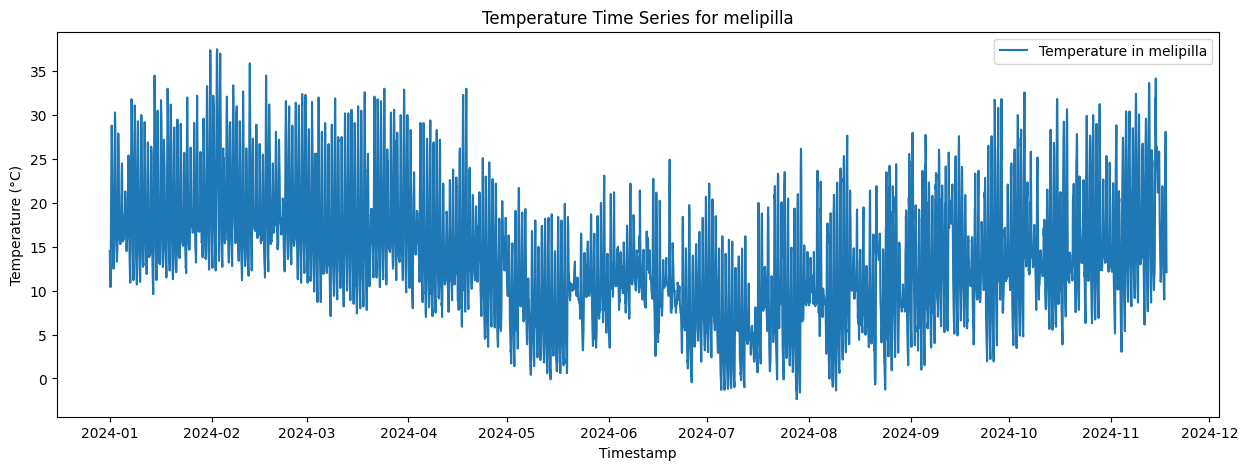

In [110]:
# Plot first series
import matplotlib.pyplot as plt
zona_to_plot = list(temperaturas.keys())[0]
temp_df = temperaturas[zona_to_plot]
plt.figure(figsize=(15, 5))
plt.plot(temp_df['fecha_datetime'], temp_df['temperatura'], label=f'Temperature in {zona_to_plot}')
plt.xlabel('Timestamp')
plt.ylabel('Temperature (°C)')
plt.title(f'Temperature Time Series for {zona_to_plot}')
plt.legend()
plt.show()

In [111]:
# Get the range of temperatures of all zones
all_temps = pd.concat([df['temperatura'] for df in temperaturas.values()])
temp_min = all_temps.min()
temp_max = all_temps.max()
print(f'Overall Temperature Range: {temp_min}°C to {temp_max}°C')

Overall Temperature Range: -5.3°C to 38.407°C


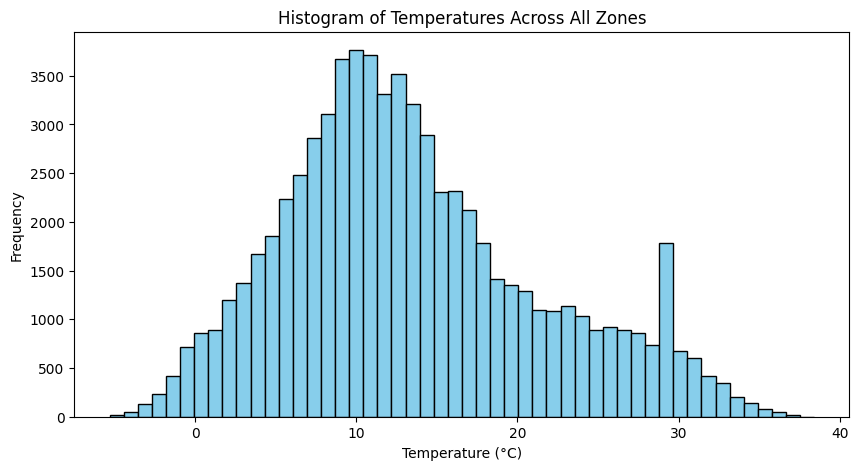

In [112]:
# Make a hist of all temperatures hours of all zones
plt.figure(figsize=(10, 5))
plt.hist(all_temps, bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.title('Histogram of Temperatures Across All Zones')
plt.show()

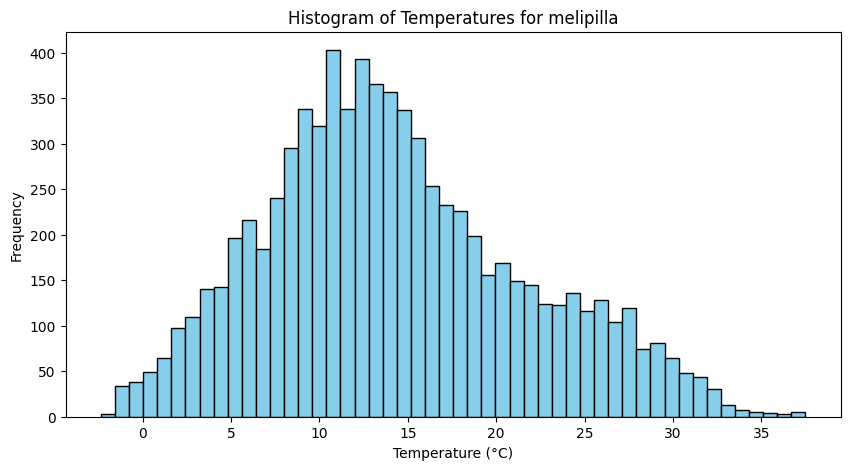

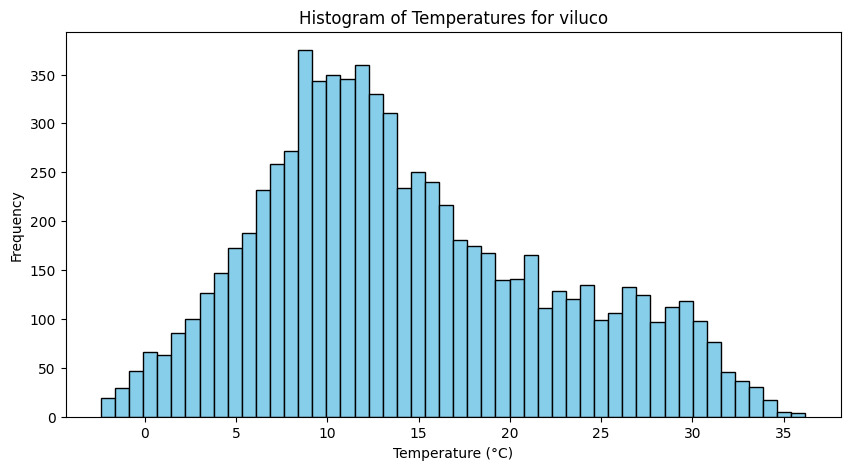

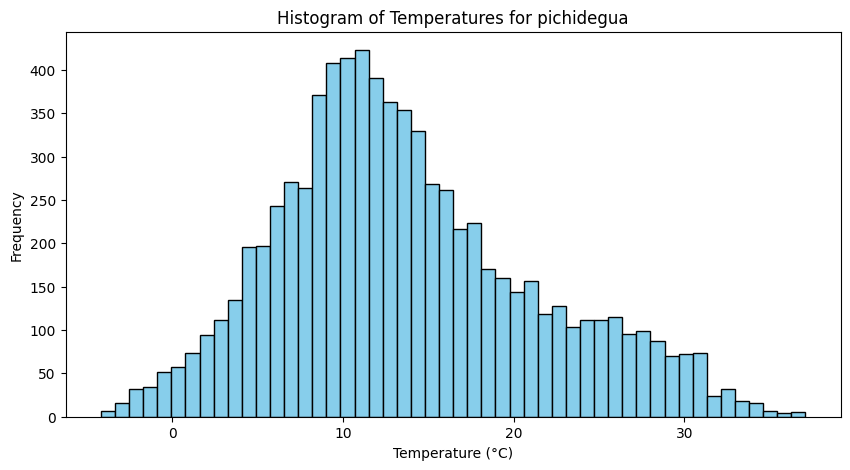

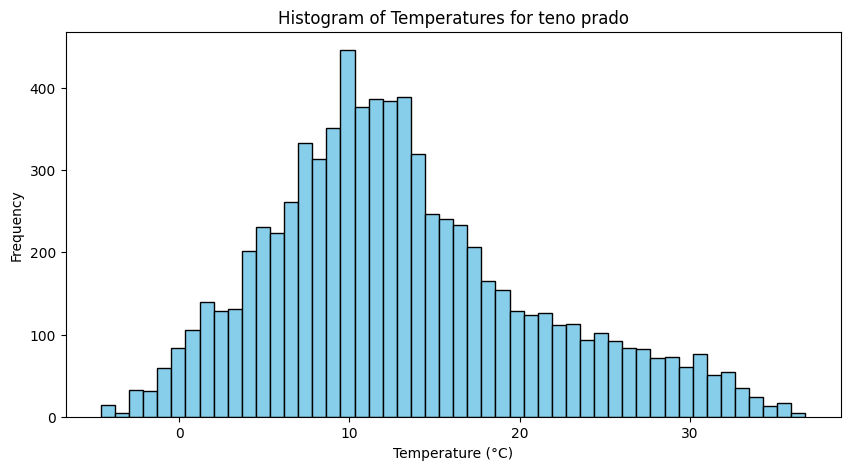

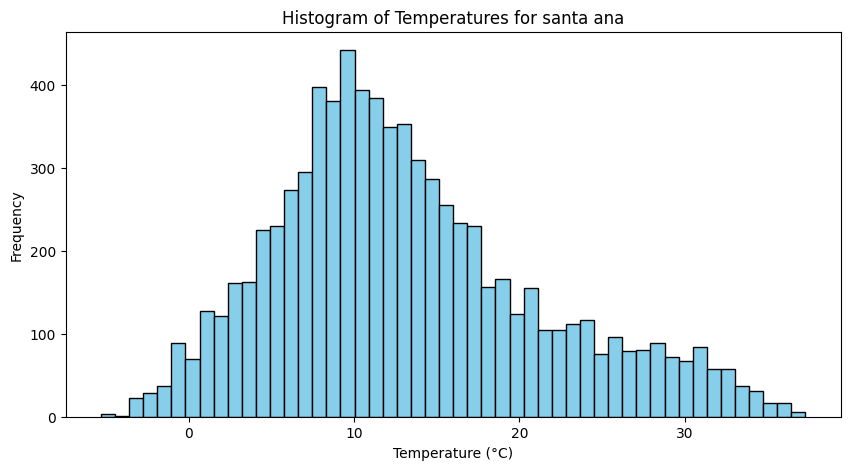

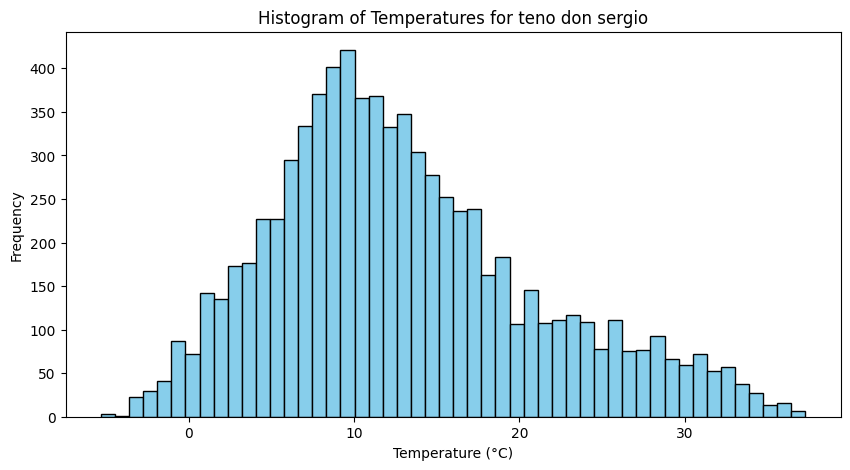

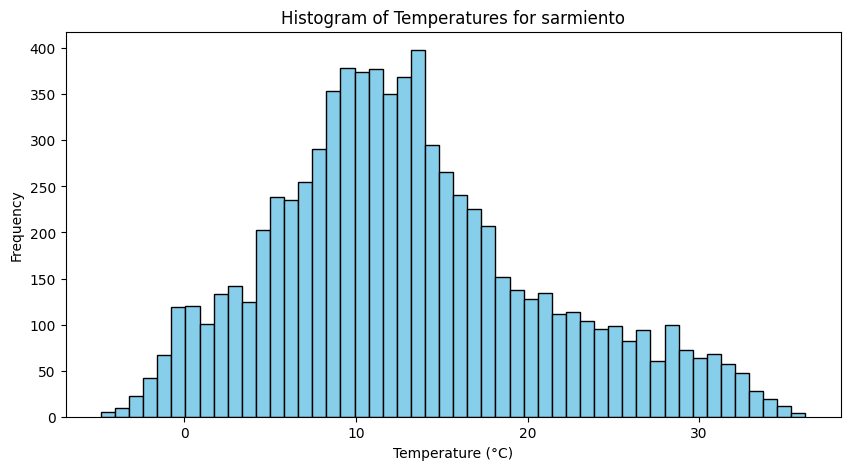

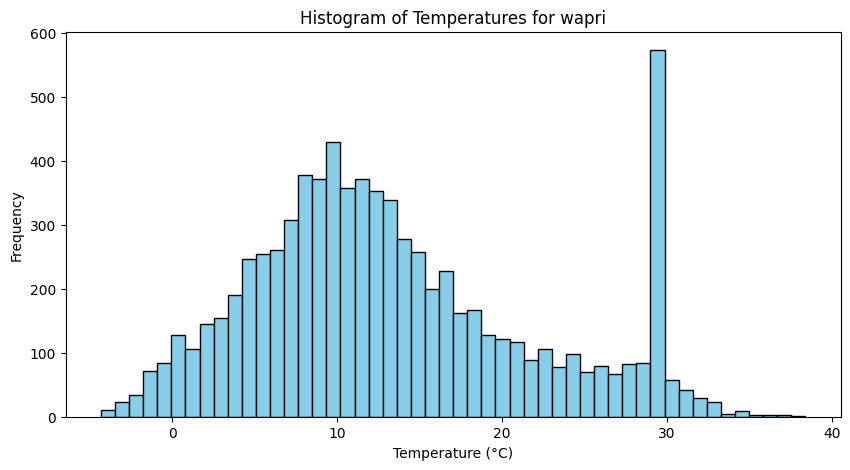

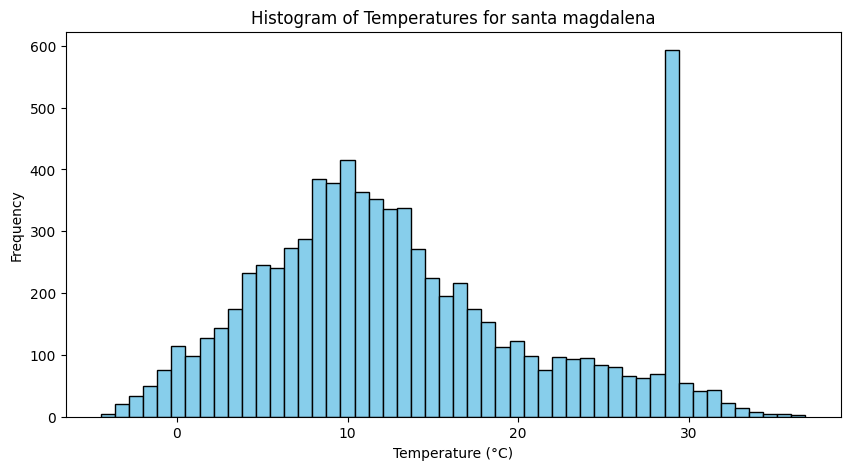

In [113]:
# Do that histogram per zone
for zona_name, temp_df in temperaturas.items():
    plt.figure(figsize=(10, 5))
    plt.hist(temp_df['temperatura'], bins=50, color='skyblue', edgecolor='black')
    plt.xlabel('Temperature (°C)')
    plt.ylabel('Frequency')
    plt.title(f'Histogram of Temperatures for {zona_name}')
    plt.show()

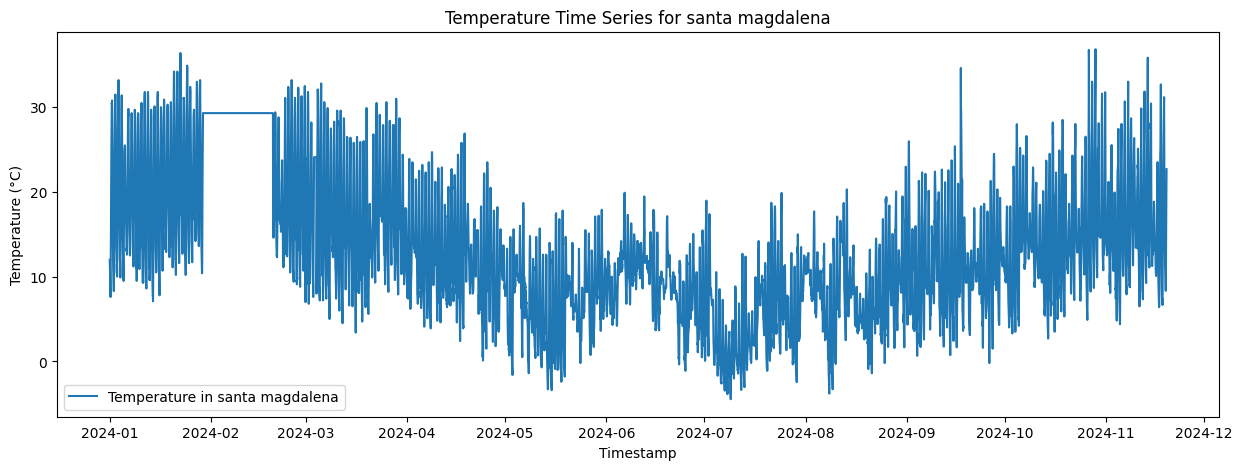

In [114]:
# Plot temperature of zone santa magdalena
zona_name = 'santa magdalena'
temp_df = temperaturas[zona_name]
plt.figure(figsize=(15, 5))
plt.plot(temp_df['fecha_datetime'], temp_df['temperatura'], label=f'Temperature in {zona_name}')
plt.xlabel('Timestamp')
plt.ylabel('Temperature (°C)')
plt.title(f'Temperature Time Series for {zona_name}')
plt.legend()
plt.show()

Obs. ese rango constante es resultado de un fill null, no es dramatico porque podemos que no importa pq esas temepraturas no las vamos a utilizar por estar fuera del rango de latencia.

In [115]:
temperaturas

{'melipilla':           fecha_datetime  temperatura
 0    2024-01-01 00:00:00         14.5
 1    2024-01-01 01:00:00         13.7
 2    2024-01-01 02:00:00         13.0
 3    2024-01-01 03:00:00         12.3
 4    2024-01-01 04:00:00         11.8
 ...                  ...          ...
 7723 2024-11-17 19:00:00         22.1
 7724 2024-11-17 20:00:00         19.4
 7725 2024-11-17 21:00:00         17.0
 7726 2024-11-17 22:00:00         14.1
 7727 2024-11-17 23:00:00         12.1
 
 [7728 rows x 2 columns],
 'viluco':           fecha_datetime  temperatura
 0    2024-01-01 00:00:00         14.2
 1    2024-01-01 01:00:00         13.3
 2    2024-01-01 02:00:00         12.3
 3    2024-01-01 03:00:00         11.8
 4    2024-01-01 04:00:00         11.2
 ...                  ...          ...
 7723 2024-11-17 19:00:00         23.9
 7724 2024-11-17 20:00:00         20.2
 7725 2024-11-17 21:00:00         17.7
 7726 2024-11-17 22:00:00         16.0
 7727 2024-11-17 23:00:00         14.4
 
 [7728 rows

In [116]:
def rename_zone(str_i):
    mapping = {
        'sta magdalena (los niches 2)': 'santa magdalena',
        'teno oriente': 'teno prado',
        'teno monta�a': 'teno don sergio',
        'teno poniente': 'santa ana',
        'wapri (los niches 1)': 'wapri',
    }
    return mapping.get(str_i, str_i)
df_p = pd.read_csv('D:\\Data\\frusan\\clean\\dataset_caida_hojas_brotacion_en_camara_ent_2024.csv', sep=";")
df_p['zona'] = df_p['zona'].apply(rename_zone)
df_p['zona'].unique(), temperaturas.keys()

(array(['melipilla', 'pichidegua', 'sarmiento', 'santa magdalena',
        'teno don sergio', 'teno prado', 'santa ana', 'viluco', 'wapri'],
       dtype=object),
 dict_keys(['melipilla', 'viluco', 'pichidegua', 'teno prado', 'santa ana', 'teno don sergio', 'sarmiento', 'wapri', 'santa magdalena']))

In [117]:
def make_group_ids(df_pheno: pd.DataFrame, variety_col="variedad", treat_col="tratamiento"):
    pairs = df_pheno[[variety_col, treat_col]].astype(str).drop_duplicates()
    pairs = list(map(tuple, pairs.values))
    pair_to_id = {p: i for i, p in enumerate(pairs)}

    group_id = df_pheno[[variety_col, treat_col]].astype(str).apply(tuple, axis=1).map(pair_to_id).astype(int)
    return group_id.to_numpy(), pair_to_id

In [118]:
import torch
from torch.utils.data import Dataset
import numpy as np

class ChillWindowDataset(Dataset):
    def __init__(
        self,
        df_pheno: pd.DataFrame,
        zone_to_temp: dict,  # zone -> pd.Series hourly temps
        zone_col: str = "zona",
        variety_col: str = "variedad",
        treat_col: str = "tratamiento",
        start_col: str = "caida_de_hojas_date",
        end_col: str = "brotacion_en_camara_50_date",
        min_hours: int = 24,   # filtra ventanas muy cortas
        max_hours: int = 24*200,  # filtra ventanas absurdas (ajusta a tu caso)
        drop_invalid: bool = True,
    ):
        self.df = df_pheno.copy()

        # Parse fechas con tz
        self.df[start_col] = pd.to_datetime(self.df[start_col], errors="coerce", dayfirst=True, format="mixed")
        self.df[end_col] = pd.to_datetime(self.df[end_col], errors="coerce", dayfirst=True, format="mixed")

        self.zone_col = zone_col
        self.start_col = start_col
        self.end_col = end_col
        self.zone_to_temp = zone_to_temp
        self.variety_col = variety_col
        self.treat_col = treat_col

        # group ids
        self.group_ids, self.pair_to_id = make_group_ids(self.df, variety_col, treat_col)

        # validity mask
        valid = self.df[zone_col].isin(zone_to_temp.keys())
        valid &= self.df[start_col].notna() & self.df[end_col].notna()
        valid &= self.df[end_col] > self.df[start_col]

        dur_hours = ((self.df[end_col] - self.df[start_col]).dt.total_seconds() / 3600.0)
        valid &= dur_hours >= min_hours
        valid &= dur_hours <= max_hours

        if drop_invalid:
            self.df = self.df[valid].reset_index(drop=True)
            self.group_ids = self.group_ids[valid.to_numpy()]
        else:
            self.valid_mask = valid.to_numpy()

        self._len = len(self.df)

    def __len__(self):
        return self._len

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        zone = row[self.zone_col]
        start = row[self.start_col]
        end = row[self.end_col]
        variety = row[self.variety_col]
        treatment = row[self.treat_col]

        s = self.zone_to_temp[zone]

        # Aseguramos slicing horario inclusivo/exclusivo consistente:
        # típicamente [start, end) (end excluido) para no contar doble si hay borde común
        window = s.loc[start:end]

        # Si quieres end excluido, usa:
        window = s.loc[start:end - pd.Timedelta(hours=1)]

        temps = torch.tensor(window.to_numpy(dtype = np.float32), dtype=torch.float32)
        group_id = int(self.group_ids[idx])

        return {
            "temps": temps, #,            # (n_hours,)
            "group_id": group_id,      # int
            "zona": zone,
            "start": start,
            "end": end,
            "variedad": variety,
            "tratamiento": treatment,
        }


In [119]:
temperaturas_input = {}
for zona_name, temp_df in temperaturas.items():
    # Set index to fecha_datetime
    temp_series = temp_df.set_index('fecha_datetime')['temperatura']
    temperaturas_input[zona_name] = temp_series

In [120]:
dataset_chill = ChillWindowDataset(
    df_pheno=df_p,
    zone_to_temp=temperaturas_input,
)

In [121]:
def dataset_sanity(ds: ChillWindowDataset, n=5):
    lengths = []
    gids = []
    for i in range(min(n, len(ds))):
        #print(f"Getting item {i}")
        try:
            item = ds[i]
        except Exception as e:
            print(f"Error getting item {i}: {e}")
            continue
        lengths.append(len(item["temps"]))
        gids.append(item["group_id"])
        print(i, item["zona"], item["variedad"], item["tratamiento"], item["start"], "to", item["end"], "hours=", len(item["temps"]), "group=", item["group_id"])
    print("len stats:", np.min(lengths), np.median(lengths), np.max(lengths))
    print("unique groups in sample:", len(set(gids)))

dataset_sanity(dataset_chill, 5)

0 melipilla santina zn+eth 2024-05-08 00:00:00 to 2024-07-09 00:00:00 hours= 1488 group= 0
1 melipilla santina fsh 2024-05-08 00:00:00 to 2024-07-12 00:00:00 hours= 1560 group= 1
2 melipilla santina control 2024-05-08 00:00:00 to 2024-07-12 00:00:00 hours= 1560 group= 2
3 melipilla santina zn+u+eth 2024-05-08 00:00:00 to 2024-07-12 00:00:00 hours= 1560 group= 3
4 melipilla santina ethephon 2024-05-15 00:00:00 to 2024-07-12 00:00:00 hours= 1392 group= 4
len stats: 1392 1560.0 1560
unique groups in sample: 5


In [122]:
import torch

def utah_piecewise(T: torch.Tensor) -> torch.Tensor:
    """
    Utah chill units (por hora) en función de temperatura T (°C).
    T: tensor (...,)
    returns: tensor (...,)
    """
    out = torch.zeros_like(T)

    # Nota: replicamos rangos típicos:
    # <=1.4 -> 0
    # 1.5-2.4 -> 0.5
    # 2.5-9.1 -> 1
    # 9.2-12.4 -> 0.5
    # 12.5-15.9 -> 0
    # 16-18 -> -0.5
    # >18 -> -1

    out = torch.where((T >= 1.5) & (T <= 2.4), torch.tensor(0.5, device=T.device, dtype=T.dtype), out)
    out = torch.where((T >= 2.5) & (T <= 9.1), torch.tensor(1.0, device=T.device, dtype=T.dtype), out)
    out = torch.where((T >= 9.2) & (T <= 12.4), torch.tensor(0.5, device=T.device, dtype=T.dtype), out)
    out = torch.where((T >= 16.0) & (T <= 18.0), torch.tensor(-0.5, device=T.device, dtype=T.dtype), out)
    out = torch.where((T > 18.0), torch.tensor(-1.0, device=T.device, dtype=T.dtype), out)

    # el resto queda 0 (incluye <1.5 y 12.5-15.9)
    return out


In [123]:
import torch
import torch.nn as nn

def rbf_features(T: torch.Tensor, centers: torch.Tensor, sigma: torch.Tensor) -> torch.Tensor:
    """
    T: (N,) o (...,) -> se aplana
    centers: (K,)
    sigma: escalar (tensor) o (K,)
    returns Phi: (N, K)
    """
    T_flat = T.reshape(-1)
    return torch.exp(-0.5 * ((T_flat[:, None] - centers[None, :]) / sigma) ** 2)

class ChillRBFModel(nn.Module):
    def __init__(self, T_min=-5.0, T_max=25.0, K=25, sigma=2.0, device="cpu"):
        super().__init__()
        centers = torch.linspace(T_min, T_max, K, device=device)
        self.register_buffer("centers", centers)
        self.register_buffer("sigma", torch.tensor(float(sigma), device=device))

        with torch.no_grad():
            # inicializamos w para aproximar Utah
            T_init = torch.linspace(self.centers.min(), self.centers.max(), 500, device=device)
            Phi = rbf_features(T_init, self.centers, self.sigma)  # (500, K)
            utah_vals = utah_piecewise(T_init)

            # ridge simple para encontrar w inicial
            reg = 1e-3 * torch.eye(Phi.shape[1], device=device)
            w0 = torch.linalg.solve(Phi.T @ Phi + reg, Phi.T @ utah_vals)

        self.w = nn.Parameter(w0.clone())
        self.b = nn.Parameter(torch.tensor(0.0, device=device))

        # alpha Utah (aprendible) # Cambiar aca si quiero quiero que sea fijo y settear loss correspondiente a 0
        self.alpha = nn.Parameter(torch.tensor(1.0, device=device))

    def f(self, T: torch.Tensor) -> torch.Tensor:
        """
        T: (...,) tensor de temperaturas
        returns: (...,) aportes por hora
        """
        Phi = rbf_features(T, self.centers, self.sigma)    # (N,K)
        y = Phi @ self.w + self.b                          # (N,)
        return y.reshape(T.shape)

    def accumulate_list(self, temps_list):
        """
        temps_list: list[Tensor] cada uno (n_hours_i,)
        returns: C (n_samples,)
        """
        C = []
        for T in temps_list:
            C.append(self.f(T).sum())
        return torch.stack(C)


In [124]:
def group_variance_loss(C: torch.Tensor, group_ids: torch.Tensor) -> torch.Tensor:
    """
    C: (n_samples,)
    group_ids: (n_samples,) long/int
    """
    loss = torch.tensor(0.0, device=C.device)
    unique = torch.unique(group_ids)
    for g in unique:
        idx = (group_ids == g)
        if idx.sum() < 2:
            continue
        x = C[idx]
        loss = loss + (x - x.mean()).pow(2).mean()
    return loss


In [125]:
def second_diff_smoothness(f_grid: torch.Tensor) -> torch.Tensor:
    """
    f_grid: (M,)
    """
    d2 = f_grid[:-2] - 2*f_grid[1:-1] + f_grid[2:]
    return (d2**2).mean()


In [126]:
def cold_penalty(f_grid: torch.Tensor, cold_mask: torch.Tensor) -> torch.Tensor:
    return torch.relu(-f_grid[cold_mask]).pow(2).mean()

def warm_penalty(f_grid: torch.Tensor, warm_mask: torch.Tensor) -> torch.Tensor:
    return torch.relu(f_grid[warm_mask]).pow(2).mean()


In [127]:
def utah_reference_loss(f_grid: torch.Tensor, utah_grid: torch.Tensor, alpha: torch.Tensor) -> torch.Tensor:
    return (f_grid - alpha * utah_grid).pow(2).mean()

def alpha_floor_loss(alpha: torch.Tensor, floor: float = 0.5) -> torch.Tensor:
    # castiga solo si alpha < floor
    return torch.relu(torch.tensor(floor, device=alpha.device) - alpha).pow(2)


In [128]:
def collate_chill(batch):
    temps_list = [b["temps"] for b in batch]
    group_ids = torch.tensor([b["group_id"] for b in batch], dtype=torch.long)
    return temps_list, group_ids


In [129]:
import torch
import pandas as pd

@torch.no_grad()
def predict_exit_date_for_unit(
    model,
    temps: torch.Tensor,          # (n_hours,)
    times: pd.DatetimeIndex,      # mismo largo que temps
    R_g: float,                   # requerimiento estimado del grupo
):
    """
    Retorna:
      - predicted_time: pd.Timestamp (o None si no alcanza R_g)
      - accumulated: valor acumulado final
    """
    model.eval()

    f_vals = model.f(temps)              # (n_hours,)
    cum = torch.cumsum(f_vals, dim=0)    # acumulado horario

    # primer índice donde supera el requerimiento
    idx = torch.where(cum >= R_g)[0]

    if len(idx) == 0:
        return None, float(cum[-1].item())

    k = int(idx[0].item())
    return times[k], float(cum[k].item())


In [130]:
@torch.no_grad()
def estimate_group_requirements(model, dataset, device="cpu"):
    """
    Retorna dict:
      group_id -> R_g (promedio de C_i en el grupo)
    """
    model.eval()

    from collections import defaultdict

    acc = defaultdict(list)

    for i in range(len(dataset)):
        item = dataset[i]
        T = item["temps"].to(device)
        g = int(item["group_id"])
        C = model.f(T).sum().item()
        acc[g].append(C)

    R_hat = {g: float(sum(v) / len(v)) for g, v in acc.items() if len(v) > 0}
    return R_hat


In [131]:
def latency_exit_error_for_dataset(
    model,
    dataset,
    group_requirements,   # dict group_id -> R_g
    device="cpu",
    max_days=30.0,
):
    """
    Calcula errores de predicción de salida de latencia.

    Retorna:
      errors_days: list[float]  (pred - real, en días)
      abs_errors_days: list[float]
    """
    errors = []
    abs_errors = []

    for i in range(len(dataset)):
        item = dataset[i]

        g = int(item["group_id"])
        if g not in group_requirements:
            continue

        R_g = group_requirements[g]

        T = item["temps"].to(device)
        times = pd.date_range(
            start=item["start"],
            periods=len(T),
            freq="H",
            tz=item["start"].tz,
        )

        t_pred, _ = predict_exit_date_for_unit(
            model=model,
            temps=T,
            times=times,
            R_g=R_g,
        )

        if t_pred is None:
            continue

        t_real = item["end"]

        delta_days = (t_pred - t_real).total_seconds() / 86400.0
        delta_days = float(delta_days)

        # opcional: recorte para estabilidad
        delta_days = max(-max_days, min(max_days, delta_days))

        errors.append(delta_days)
        abs_errors.append(abs(delta_days))

    return errors, abs_errors


In [132]:
from torch.utils.data import DataLoader

def train_chill_model(
    dataset,
    device="cpu",
    T_min=-5.0, T_max=35.0, K=40, sigma=1.0,
    # rangos guía
    cold_range=(0.0, 9.0),
    warm_range=(16.0, 30.0),
    # lambdas
    lam_u=1.0, lam_s=1, lam_c=1000, lam_w=1000, lam_a=100,
    alpha_floor=1,
    # training
    batch_size=64, steps=2000, lr=1e-1,
    grid_points=400,
):
    dl = DataLoader(dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_chill)

    model = ChillRBFModel(T_min=T_min, T_max=T_max, K=K, sigma=sigma, device=device).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    # grilla para regularizaciones y Utah prior
    T_grid = torch.linspace(T_min, T_max, grid_points, device=device)
    utah_grid = utah_piecewise(T_grid)

    cold_mask = (T_grid >= cold_range[0]) & (T_grid <= cold_range[1])
    warm_mask = (T_grid >= warm_range[0]) & (T_grid <= warm_range[1])

    it = iter(dl)

    for step in range(steps):
        try:
            temps_list, group_ids = next(it)
        except StopIteration:
            it = iter(dl)
            temps_list, group_ids = next(it)

        temps_list = [t.to(device) for t in temps_list]
        group_ids = group_ids.to(device)

        opt.zero_grad()

        # acumulados por muestra
        C = model.accumulate_list(temps_list)  # (B,)

        # términos
        L_var = group_variance_loss(C, group_ids)

        f_grid = model.f(T_grid)              # (M,)
        L_ref = utah_reference_loss(f_grid, utah_grid, model.alpha)
        L_smooth = second_diff_smoothness(f_grid)
        L_cold = cold_penalty(f_grid, cold_mask)
        L_warm = warm_penalty(f_grid, warm_mask)
        L_alpha = alpha_floor_loss(model.alpha, floor=alpha_floor)

        loss = (L_var
                + lam_u * L_ref
                + lam_s * L_smooth
                + lam_c * L_cold
                + lam_w * L_warm
                + lam_a * L_alpha)

        loss.backward()
        opt.step()

        if step % 200 == 0:
            print(
                f"step={step:4d} loss={loss.item():.4f} "
                f"Lvar={L_var.item():.4f} Lref={L_ref.item():.4f} "
                f"Ls={L_smooth.item():.4f} Lc={L_cold.item():.4f} "
                f"Lw={L_warm.item():.4f} alpha={model.alpha.item():.3f}"
            )

    return model


In [133]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = train_chill_model(
    dataset=dataset_chill,
    device=device
)


step=   0 loss=94953.9141 Lvar=94953.9062 Lref=0.0103 Ls=0.0000 Lc=0.0000 Lw=0.0000 alpha=0.900
step= 200 loss=30.3569 Lvar=30.0289 Lref=0.2156 Ls=0.0000 Lc=0.0048 Lw=0.0032 alpha=0.677
step= 400 loss=42.3283 Lvar=42.0132 Lref=0.2102 Ls=0.0000 Lc=0.0061 Lw=0.0028 alpha=0.689
step= 600 loss=52.7402 Lvar=52.4304 Lref=0.2084 Ls=0.0000 Lc=0.0047 Lw=0.0027 alpha=0.686
step= 800 loss=52.3434 Lvar=52.0451 Lref=0.2001 Ls=0.0000 Lc=0.0050 Lw=0.0032 alpha=0.708
step=1000 loss=66.1109 Lvar=65.7978 Lref=0.2423 Ls=0.0000 Lc=0.0060 Lw=0.0044 alpha=0.736
step=1200 loss=527.3973 Lvar=527.1146 Lref=0.1951 Ls=0.0000 Lc=0.0033 Lw=0.0035 alpha=0.735
step=1400 loss=773.9750 Lvar=773.6596 Lref=0.2079 Ls=0.0000 Lc=0.0046 Lw=0.0038 alpha=0.662
step=1600 loss=3519.3682 Lvar=3518.8093 Lref=0.3923 Ls=0.0000 Lc=0.0005 Lw=0.1114 alpha=0.674
step=1800 loss=25.8414 Lvar=25.5038 Lref=0.2682 Ls=0.0000 Lc=0.0045 Lw=0.0023 alpha=0.749


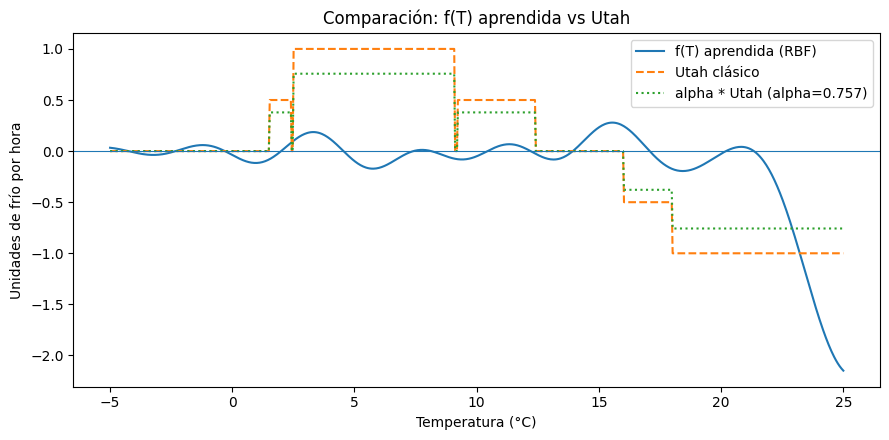

In [134]:
import torch
import matplotlib.pyplot as plt

# Asume que ya tienes:
# - model (ChillRBFModel entrenado)
# - utah_piecewise(T) definida

def plot_learned_vs_utah(model, T_min=-5.0, T_max=25.0, n=600, device=None, title=None):
    if device is None:
        device = next(model.parameters()).device

    T = torch.linspace(T_min, T_max, n, device=device)

    model.eval()
    with torch.no_grad():
        f_learned = model.f(T)                          # (n,)
        f_utah = utah_piecewise(T)                      # (n,)
        alpha = float(model.alpha.detach().cpu())

    # a numpy para plot
    T_np = T.detach().cpu().numpy()
    fL_np = f_learned.detach().cpu().numpy()
    fU_np = f_utah.detach().cpu().numpy()
    fUa_np = alpha * fU_np

    plt.figure(figsize=(9, 4.5))
    plt.plot(T_np, fL_np, label="f(T) aprendida (RBF)")
    plt.plot(T_np, fU_np, "--", label="Utah clásico")
    plt.plot(T_np, fUa_np, ":", label=f"alpha * Utah (alpha={alpha:.3f})")
    plt.axhline(0.0, linewidth=0.8)
    plt.xlabel("Temperatura (°C)")
    plt.ylabel("Unidades de frío por hora")
    plt.title(title or "Comparación: f(T) aprendida vs Utah")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ---- Llamada ----
plot_learned_vs_utah(model, T_min=-5, T_max=25, n=800)
